# <center>EDA</center>

In [1]:
# Importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [2]:
# Loading the cleaned dataset
df = pd.read_csv('data/cleaned_dataset.csv')

In [3]:
# Checking the shape
df.shape

(10000, 14)

In [4]:
# Checking the first 5 rows
df.head()

,row_number,customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# Separating the num and cat columns
# Removing exited from numerical cols lists
num_cols = df.select_dtypes(include='number').columns.drop(['exited', 'row_number', 'customer_id'])

# Removing surname from cat cols because it is high cardinality
cat_cols = df.select_dtypes(exclude='number').columns.drop('surname')

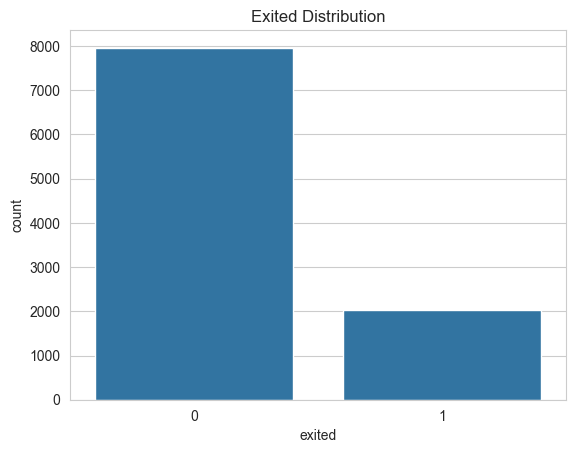

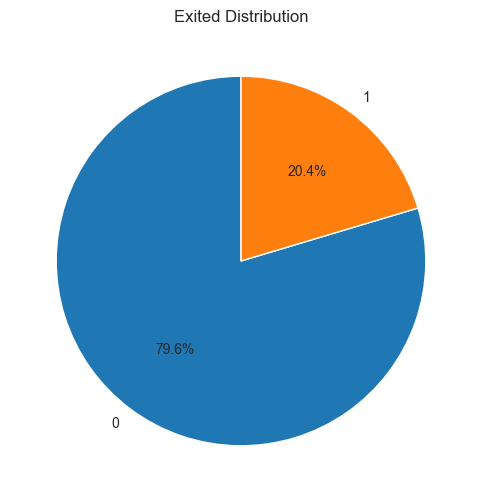

exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [6]:
# Checking the distribution of target variable
sns.countplot(x=df["exited"], data=df)
plt.title('Exited Distribution')
plt.show()

# Pie chart
count = df['exited'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(count.values, labels=count.index, autopct='%1.1f%%', startangle=90)
plt.title(f'Exited Distribution')
plt.show()

# value_counts
df['exited'].value_counts(normalize=True)

### Insights:
- Around 79.6% customers did not churn, while 20.4% customers churned
- The dataset shows a clear class imbalance between churn and non-churn customers
- The model may become biased toward predicting the majority class (non-churn)
- Evaluation metrics like accuracy alone may not be sufficient
- Additional metrics like precision, recall, and F1-score should be considered

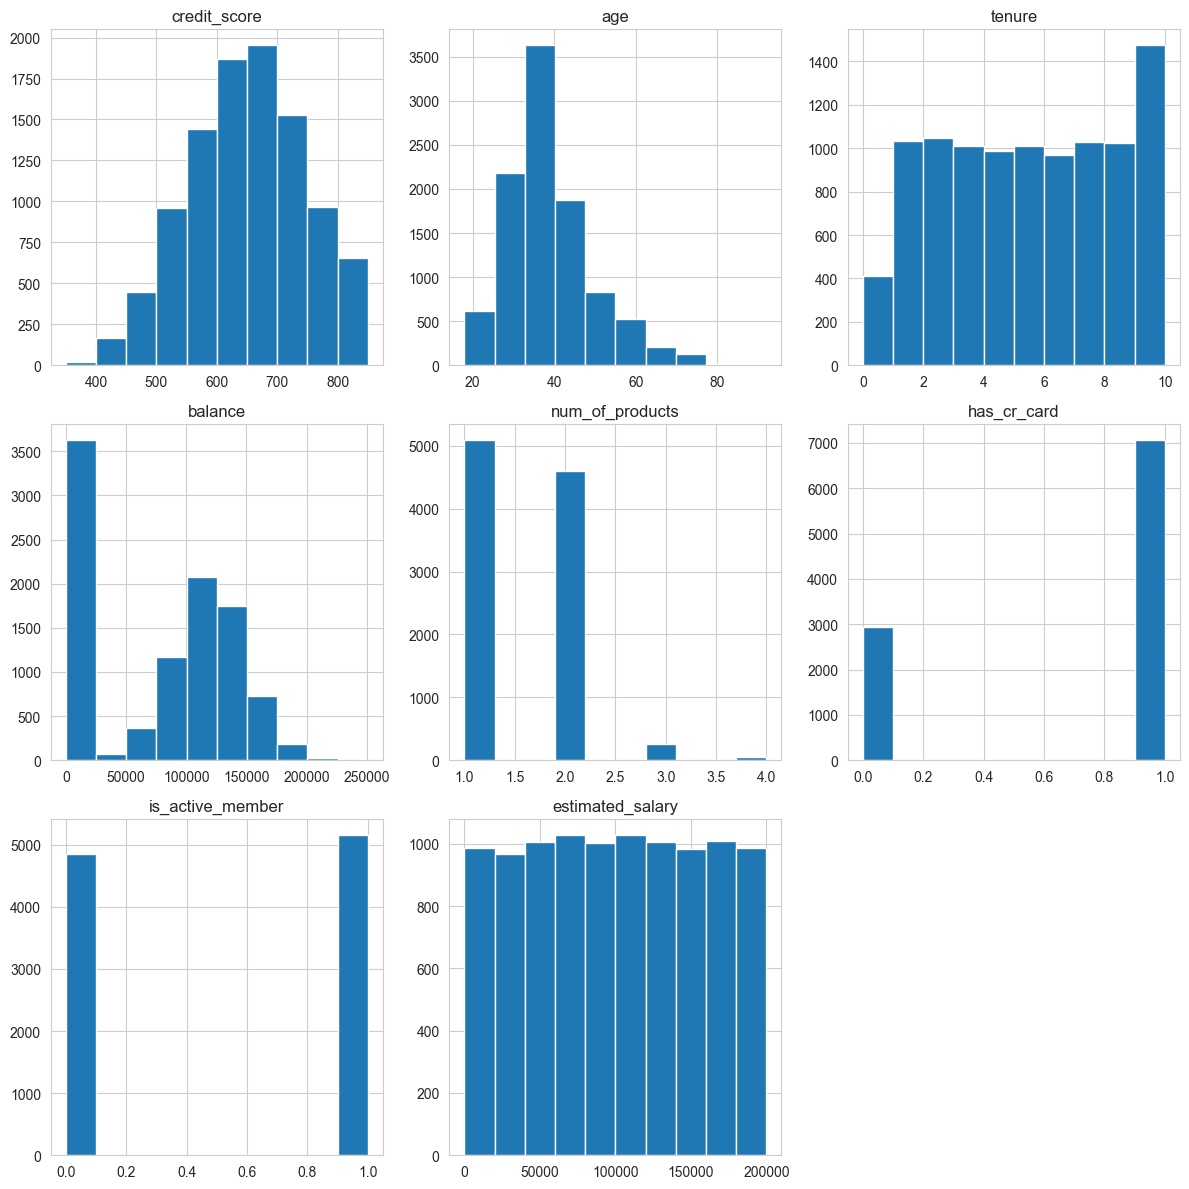

In [7]:
# Checking the distribution of numerical columns
df[num_cols].hist(figsize=(12,12))
plt.tight_layout()
plt.show()

### Insights
- credit_score shows a roughly normal distribution, with most values concentrated around the middle range
- age is right-skewed, with most customers in the 30–40 range and fewer older customers
- tenure appears uniformly distributed, indicating customers are spread across all tenure values
- balance shows a large spike at zero, meaning many customers have no balance, and the rest are widely spread
- balance also appears skewed, indicating need for possible transformation
- num_of_products is discrete and concentrated around 1 and 2, with very few customers using 3 or 4 products
- has_cr_card is imbalanced, with more customers having a credit card
- is_active_member is almost evenly distributed between active and inactive customers
- estimated_salary appears uniformly distributed, with no clear skewness or concentration

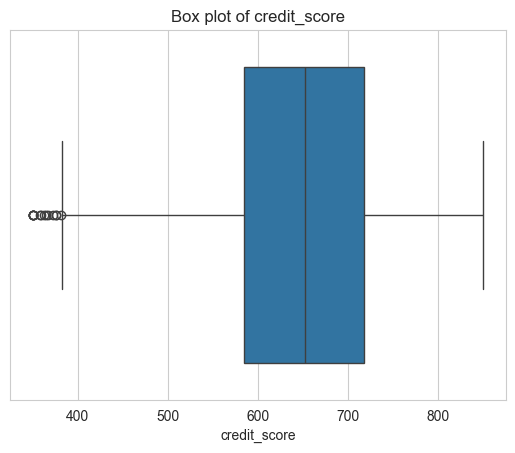

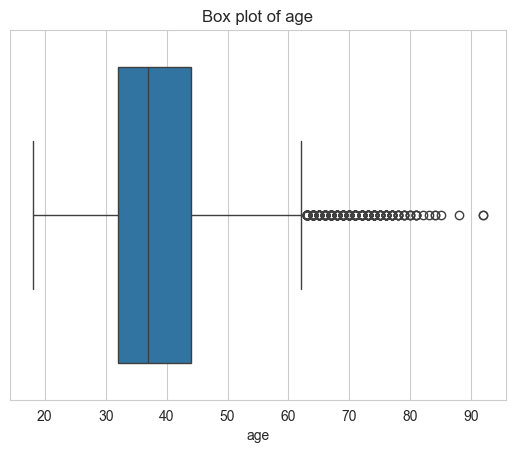

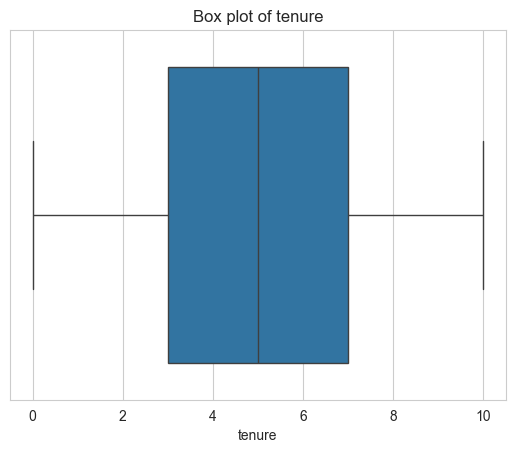

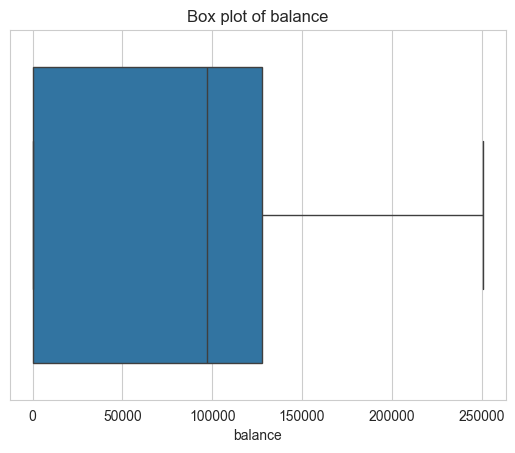

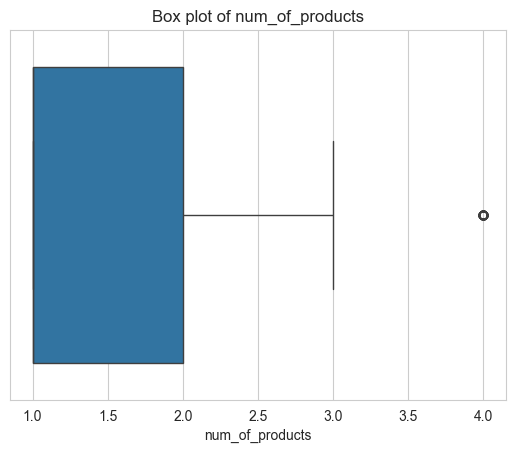

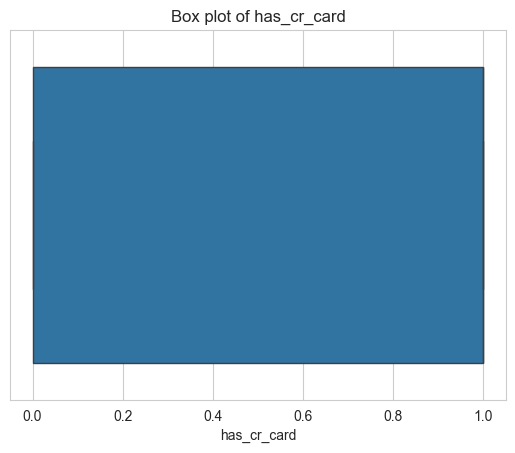

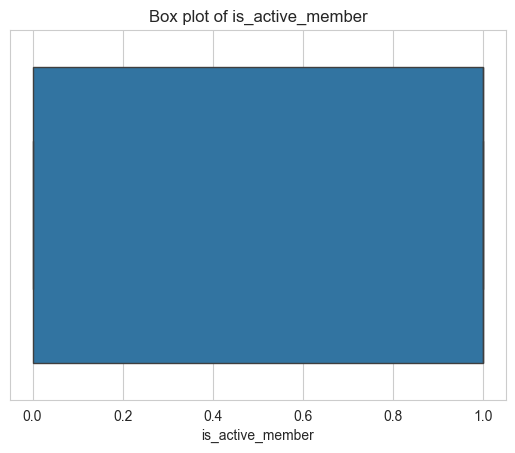

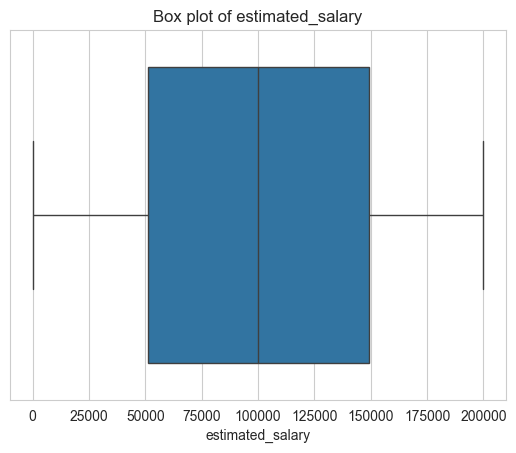

In [8]:
# Checking for the outliers using box plot
for cols in num_cols:
    sns.boxplot(x=cols, data=df)
    plt.title(f"Box plot of {cols}")
    plt.show()

In [9]:
# Outlier Summary

def outlier_summary_all(df):
    summaries = []
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
        summaries.append({
            "column": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outliers.shape[0],
            "outlier_percentage": outliers.shape[0] / df.shape[0] * 100
        })
    
    return pd.DataFrame(summaries)

outlier_summary_all(df)

,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,credit_score,584.00,718.0000,134.0000,383.00000,919.00000,15,0.15
1,age,32.00,44.0000,12.0000,14.00000,62.00000,359,3.59
2,tenure,3.00,7.0000,4.0000,-3.00000,13.00000,0,0.00
3,balance,0.00,127644.2400,127644.2400,-191466.36000,319110.60000,0,0.00
4,num_of_products,1.00,2.0000,1.0000,-0.50000,3.50000,60,0.60
5,has_cr_card,0.00,1.0000,1.0000,-1.50000,2.50000,0,0.00
6,is_active_member,0.00,1.0000,1.0000,-1.50000,2.50000,0,0.00
7,estimated_salary,51002.11,149388.2475,98386.1375,-96577.09625,296967.45375,0,0.00


### Insights
- credit_score has very few outliers (0.15%), so impact is minimal
- age has noticeable outliers (~3.6%), indicating presence of extreme age values
- num_of_products has some outliers (0.6%), mainly due to rare higher values
- balance shows no outliers detected by IQR, but earlier distribution showed many zero values
- estimated_salary has no outliers, indicating stable distribution
- tenure has no outliers, values are within expected range
- has_cr_card and is_active_member show no outliers, as they are binary features

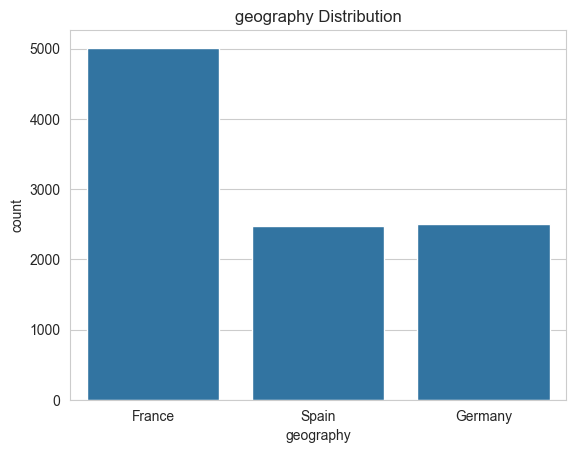

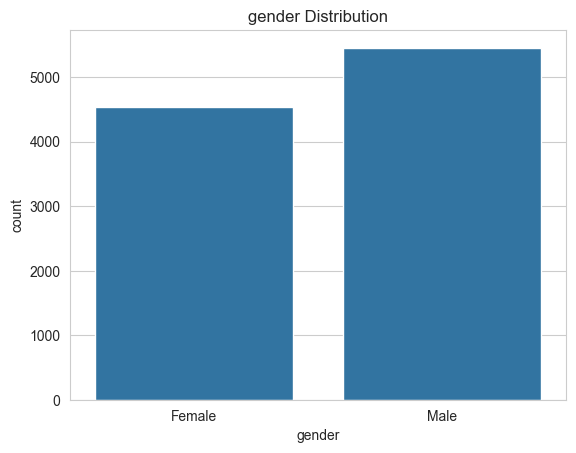

In [10]:
# Checking the distribution of categorical columns
for col in cat_cols:
    sns.countplot(x=df[col], data=df)
    plt.title(f'{col} Distribution')
    plt.show()

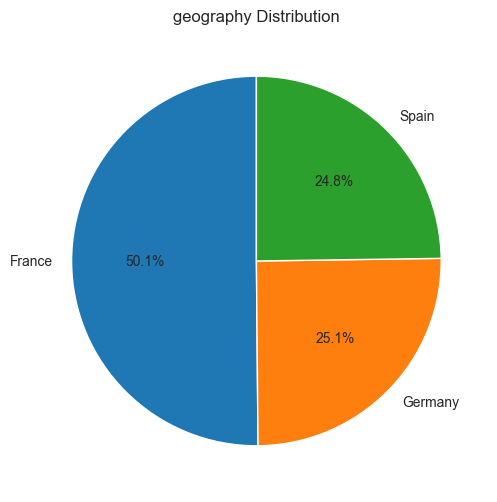

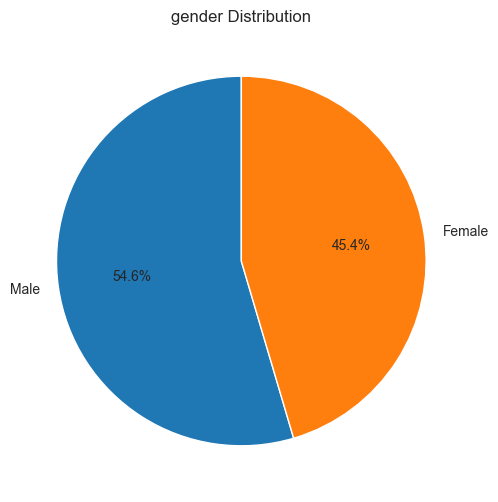

In [11]:
# Checking the distribution of Categorical using pie chart
for col in cat_cols:
    count = df[col].value_counts()

    plt.figure(figsize=(6,6))
    plt.pie(count.values, labels=count.index, autopct='%1.1f%%', startangle=90)
    plt.title(f'{col} Distribution')
    plt.show()

### Insights
- Majority of customers are from France (50.1%), while Spain and Germany have similar proportions (~25% each)
- The dataset is not evenly distributed by geography, with France dominating
- Male customers (54.6%) are slightly more than female customers (45.4%)
- Gender distribution is fairly balanced, with no extreme imbalance
- Both geography and gender have sufficient representation across categories for analysis

In [12]:
# Checking the cross tabulation between categorical and target
for col in cat_cols:
    print(pd.crosstab(df[col], df['exited'], normalize='index'))

exited            0         1
geography                    
France     0.838452  0.161548
Germany    0.675568  0.324432
Spain      0.833266  0.166734
exited         0         1
gender                    
Female  0.749285  0.250715
Male    0.835441  0.164559


### Insights
- Customers from Germany have the highest churn rate (~32%) compared to France and Spain (~16–17%)
- France and Spain show similar churn patterns, with majority of customers not churning
- Female customers have higher churn (~25%) compared to male customers (~16%)
- Male customers are more likely to stay, as a higher proportion falls in non-churn category
- Geography and gender both show clear differences in churn behavior, making them important features for modeling

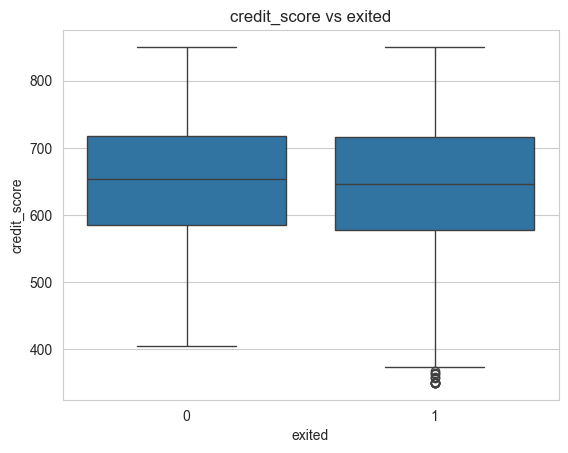

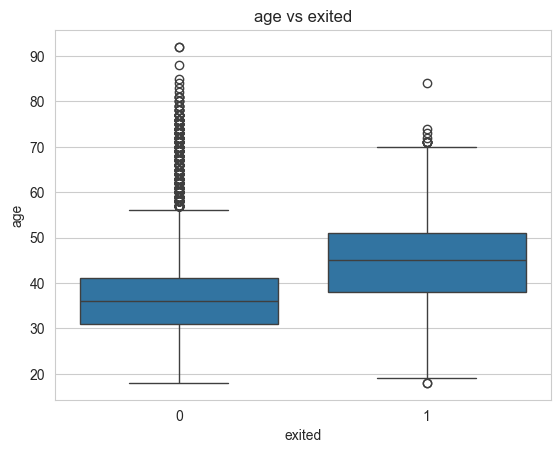

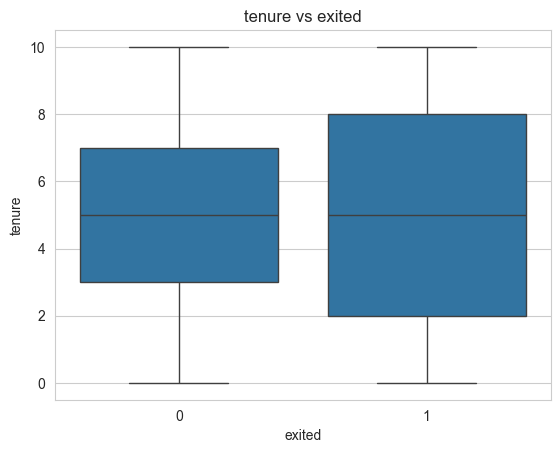

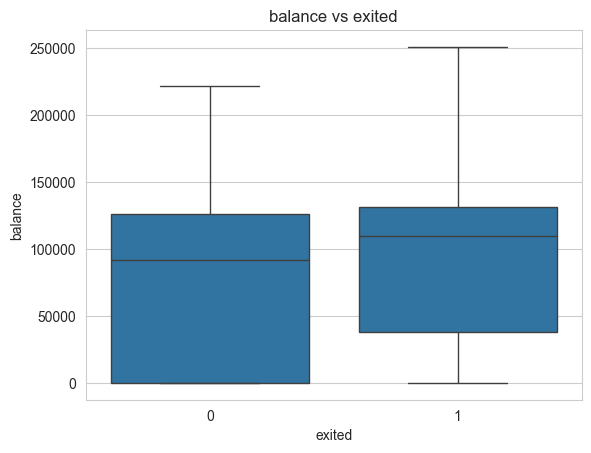

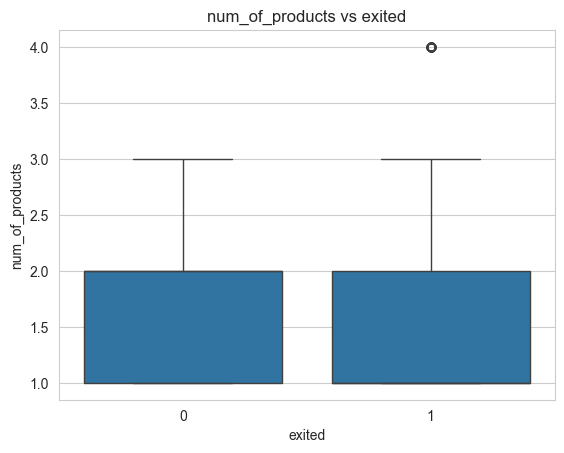

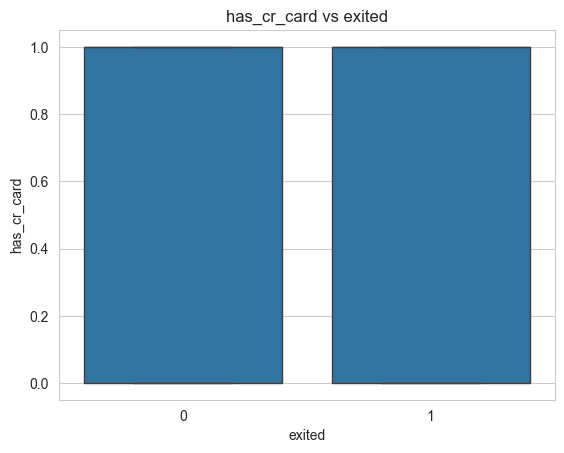

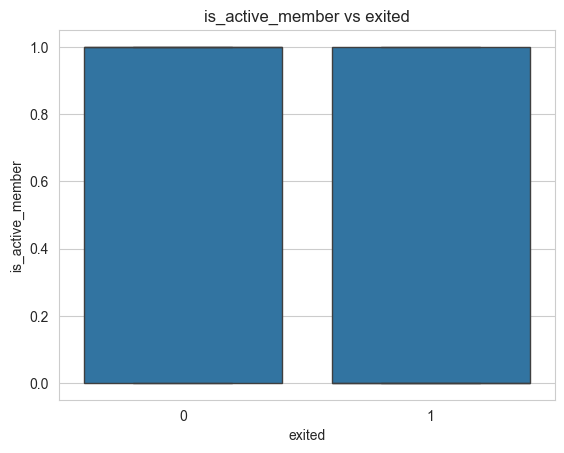

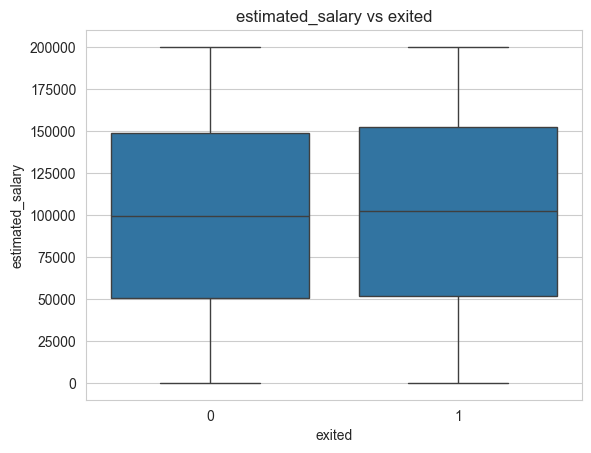

In [13]:
# Numerical columns Vs Target
for col in num_cols:
    plt.figure()
    sns.boxplot(x='exited', y=col, data=df)
    plt.title(f"{col} vs exited")
    plt.show()

### Insights
- credit_score shows very similar distribution for churned and non-churned customers, indicating weak impact
- age shows a clear difference, with churned customers generally having higher age
- tenure shows no strong variation between churn and non-churn
- balance is slightly higher for churned customers, but overlap is significant
- num_of_products shows some difference, with churn more visible at certain product counts
- has_cr_card shows almost identical distribution, indicating no meaningful impact
- is_active_member shows a clear difference, with inactive members having more churn
- estimated_salary shows no clear separation, indicating weak relationship with churn

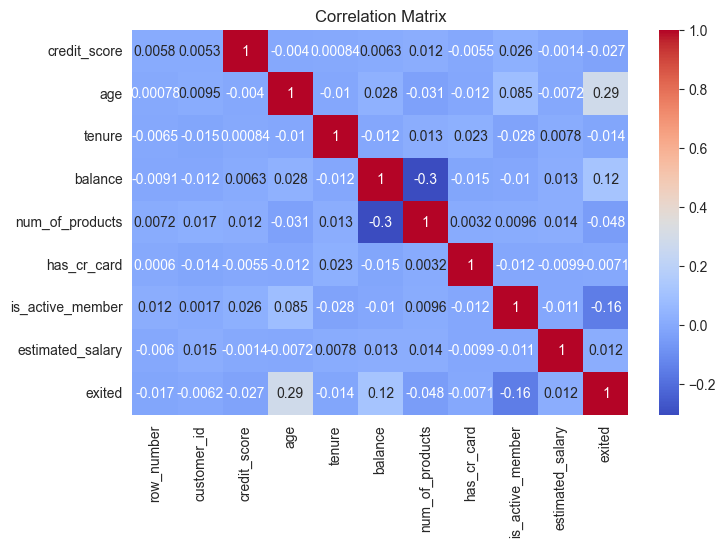

In [14]:
# Correlation matrix
corr = df.corr(numeric_only=True).drop(['row_number', 'customer_id'])

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Insights
- age shows the strongest positive correlation with churn (~0.285) among all features
- balance has a moderate positive correlation with churn (~0.118)
- is_active_member has a negative correlation with churn (~-0.156), indicating active members are less likely to churn
- num_of_products has a slight negative correlation (~-0.048) with churn
- credit_score, tenure, has_cr_card, and estimated_salary show very weak or negligible correlation with churn
- balance and num_of_products have a moderate negative correlation (~-0.304) with each other
- Most features show low correlation with churn, indicating no strong linear relationships except a few
- There is no strong multicollinearity among most features, which is good for modeling

<Figure size 10000x10000 with 0 Axes>

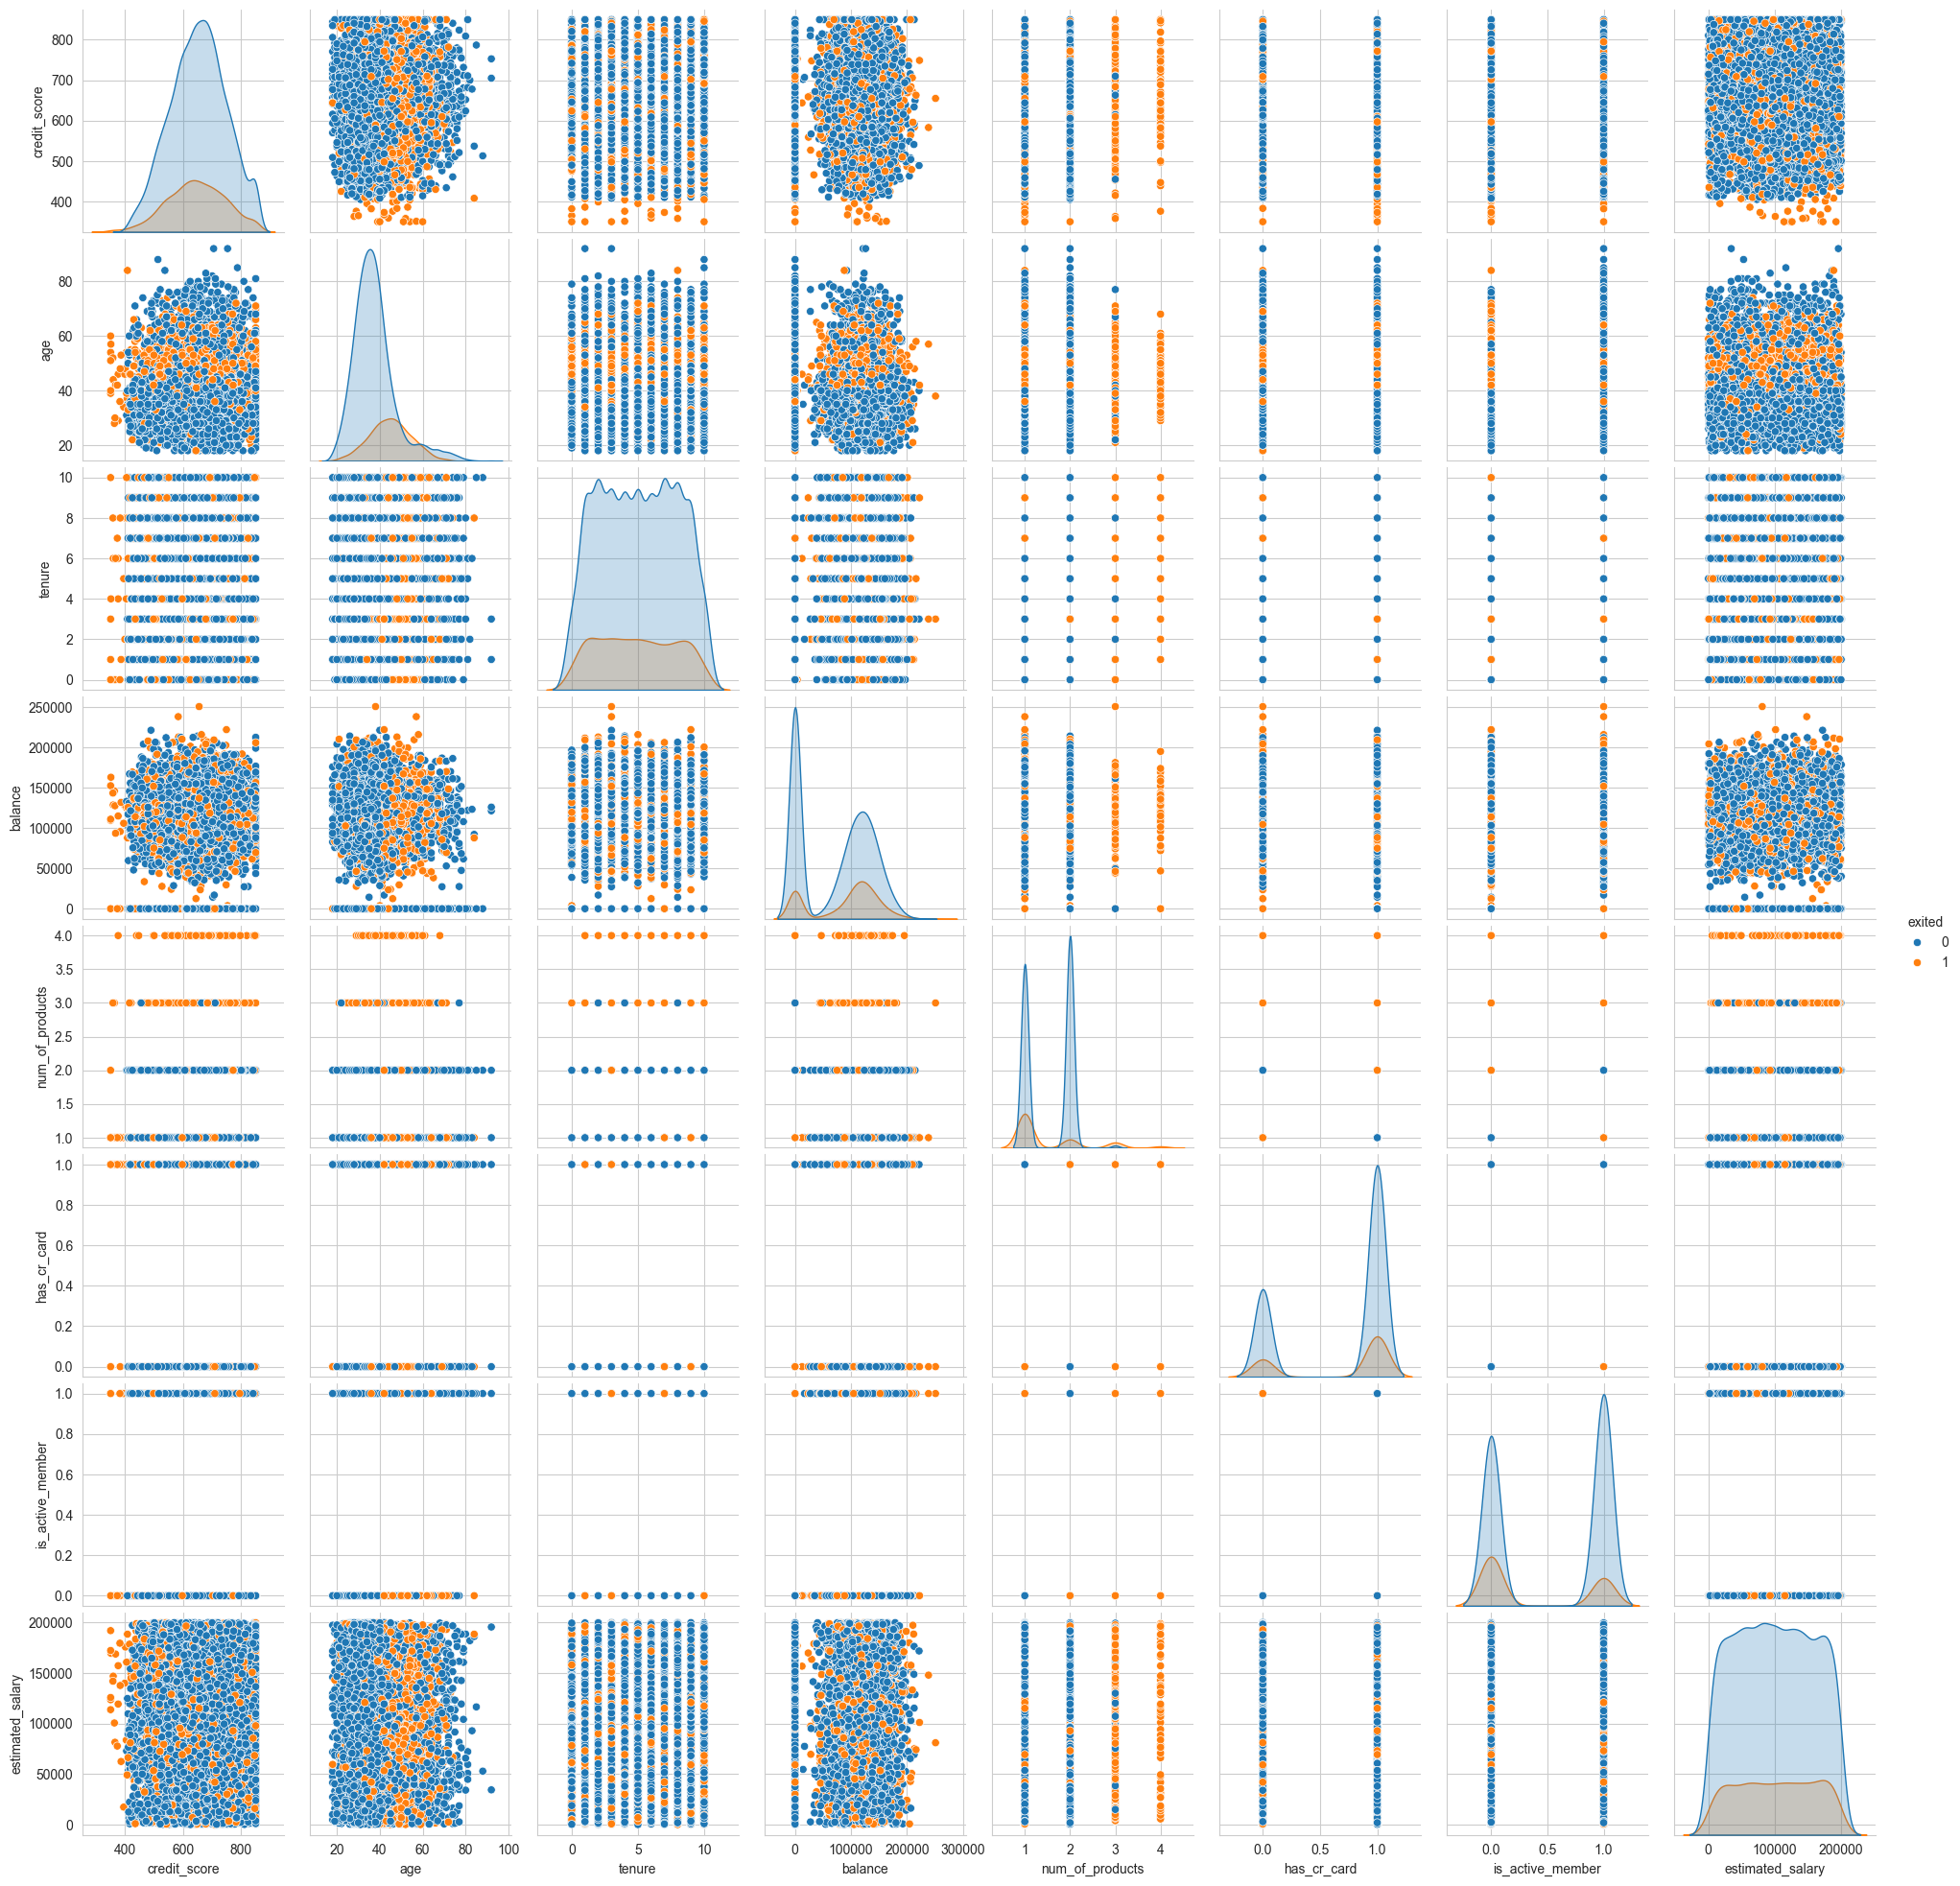

In [22]:
# Checking the pairplot with target
plt.figure(figsize=(100,100))
sns.pairplot(df, hue='exited')
plt.show()

### Insights
- age shows a clear separation pattern, where higher ages have more churn instances
- balance shows that customers with higher balance tend to have more churn cases
- is_active_member shows a visible difference, with inactive members having more churn
- num_of_products shows that churn is more concentrated in specific product counts (especially 1 and 2)
- credit_score does not show any clear separation between churn and non-churn
- tenure does not show a strong visible relationship with churn
- has_cr_card does not show any noticeable difference between churn and non-churn
- estimated_salary appears uniform with no visible pattern related to churn
- Most relationships are non-linear and overlapping, indicating need for models like ANN
- Only a few features like age, balance, and activity status show meaningful patterns with churn

In [16]:
# Droping some useless columns i.e. 'row_number', 'customer_id', 'surname'
df = df.drop(columns=['row_number', 'customer_id', 'surname'], axis=1)

In [17]:
# Checking the first five rows of final df
df.head()

,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [18]:
# Saving the new dataset
df.to_csv("data/final_data.csv", index=False)

In [24]:
df.columns

Index(['credit_score', 'geography', 'gender', 'age', 'tenure', 'balance',
       'num_of_products', 'has_cr_card', 'is_active_member',
       'estimated_salary', 'exited'],
      dtype='object')